In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
DATASET_ROOT = "/content/drive/MyDrive/Dataset-COCO-Final/Dataset-COCO-Final"

TRAIN_JSON = f"{DATASET_ROOT}/train/_annotations.coco.json"
VAL_JSON   = f"{DATASET_ROOT}/val/_annotations.coco.json"

TRAIN_IMG_DIR = f"{DATASET_ROOT}/train"
VAL_IMG_DIR   = f"{DATASET_ROOT}/val"


In [3]:
# Install dependencies
!apt-get update
!apt-get install -y build-essential cmake git libgtk2.0-dev pkg-config libavcodec-dev libavformat-dev libswscale-dev

# Clone repo (or update if already cloned)
!rm -rf detectron2
!git clone https://github.com/facebookresearch/detectron2.git
%cd detectron2

# Build and install
!python -m pip install -e .


Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [4]:
import detectron2
from detectron2.utils.logger import setup_logger

setup_logger()
print("✅ Detectron2 is installed and ready!")


✅ Detectron2 is installed and ready!


In [7]:
# ================================
# 5️⃣ Imports
# ================================
import random
import cv2
import matplotlib.pyplot as plt
import torch

from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import Visualizer
from detectron2 import model_zoo
from detectron2.data.datasets import register_coco_instances

DATASET_ROOT = "/content/drive/MyDrive/Dataset-COCO-Final/Dataset-COCO-Final"

register_coco_instances(
    "pak_food_train",
    {},
    f"{DATASET_ROOT}/train/_annotations.coco.json",
    f"{DATASET_ROOT}/train"
)

register_coco_instances(
    "pak_food_val",
    {},
    f"{DATASET_ROOT}/val/_annotations.coco.json",
    f"{DATASET_ROOT}/val"
)
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/MaskRCNN-SEGFULL"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)

# -----------------------------
# Dataset
# -----------------------------
cfg.DATASETS.TRAIN = ("pak_food_train",)
cfg.DATASETS.TEST  = ("pak_food_val",)

# -----------------------------
# Dataloader
# -----------------------------
cfg.DATALOADER.NUM_WORKERS = 2

# -----------------------------
# Model
# -----------------------------
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
)

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 86
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128

cfg.MODEL.DEVICE = "cuda"

# -----------------------------
# Solver (IMPORTANT PART)
# -----------------------------
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025

# 28k images → ~14k iters per epoch
# 8–10 epochs is reasonable
cfg.SOLVER.MAX_ITER = 120_000

cfg.SOLVER.STEPS = (80_000, 100_000)  # LR decay
cfg.SOLVER.GAMMA = 0.1

cfg.SOLVER.CHECKPOINT_PERIOD = 5_000  # 🔑 resume-safe

# -----------------------------
# Output
# -----------------------------
cfg.OUTPUT_DIR = CHECKPOINT_DIR
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)


In [8]:
CHECKPOINT_PATH = "/content/drive/MyDrive/MaskRCNN-SEGFULL/model_0084999.pth"

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)



In [9]:

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 86
cfg.MODEL.WEIGHTS = CHECKPOINT_PATH
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5 # confidence threshold
predictor = DefaultPredictor(cfg)

[02/20 19:42:50 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/MaskRCNN-SEGFULL/model_0084999.pth ...


✅ Debugging folder: /content/drive/MyDrive/MaskRCNN-SEGFULL
├── coco_instances_results.json
├── events.out.tfevents.1769935944.217499294f5a.1281.0
├── events.out.tfevents.1770040147.404036c248a1.452.0
├── events.out.tfevents.1770045689.404036c248a1.452.1
├── events.out.tfevents.1770370766.1c50de1b946c.452.0
├── events.out.tfevents.1770460095.9cd8a222940e.333.0
├── events.out.tfevents.1770465014.9cd8a222940e.333.1
├── instances_predictions.pth
├── last_checkpoint
├── metrics.json
├── model_0004999.pth
├── model_0009999.pth
├── model_0014999.pth
├── model_0019999.pth
├── model_0024999.pth
├── model_0029999.pth
├── model_0034999.pth
├── model_0039999.pth
├── model_0044999.pth
├── model_0049999.pth
├── model_0054999.pth
├── model_0059999.pth
├── model_0064999.pth
├── model_0069999.pth
├── model_0074999.pth
├── model_0079999.pth
├── model_0084999.pth
├── val_results.json
├── validation_results.json


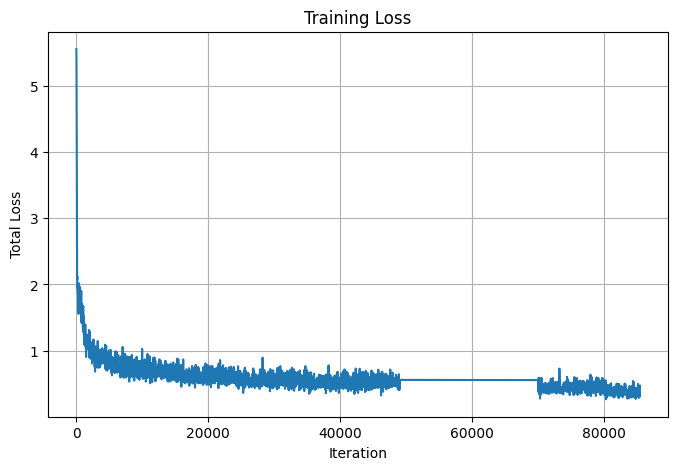

In [10]:
import os
from pathlib import Path

SEG_DIR = "/content/drive/MyDrive/MaskRCNN-SEGFULL"

assert os.path.exists(SEG_DIR), "❌ Folder does not exist!"
print("✅ Debugging folder:", SEG_DIR)
def print_tree(root, level=0):
    prefix = "│   " * level + "├── "
    for item in sorted(os.listdir(root)):
        path = os.path.join(root, item)
        print(prefix + item)
        if os.path.isdir(path):
            print_tree(path, level + 1)

print_tree(SEG_DIR)
import json
import matplotlib.pyplot as plt

metrics_path = "/content/drive/MyDrive/MaskRCNN-SEGFULL/metrics.json"

iters, loss = [], []

with open(metrics_path) as f:
    for line in f:
        data = json.loads(line)
        if "total_loss" in data:
            iters.append(data["iteration"])
            loss.append(data["total_loss"])

plt.figure(figsize=(8,5))
plt.plot(iters, loss)
plt.xlabel("Iteration")
plt.ylabel("Total Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [11]:
import json

COCO_JSON = "/content/drive/MyDrive/Dataset-COCO-Final/Dataset-COCO-Final/train/_annotations.coco.json"

with open(COCO_JSON, "r") as f:
    coco_data = json.load(f)

# Sort by category id (VERY important)
categories = sorted(coco_data["categories"], key=lambda x: x["id"])
class_names = [cat["name"] for cat in categories]

print("Number of classes:", len(class_names))
print("First 10 classes:", class_names[:10])

Number of classes: 86
First 10 classes: ['objects', 'achar_pickle', 'aloo_baingan', 'aloo_gobi', 'aloo_gosht', 'aloo_methi', 'aloo_palak', 'aloo_shimla_mirch', 'aloo_tahari', 'aloo_vanda_aloo_wale_parathe___aloo_snacks']


In [12]:
from detectron2.data import MetadataCatalog

metadata = MetadataCatalog.get("pak_food_train")
metadata.thing_classes = class_names

In [14]:
img = cv2.imread("/content/drive/MyDrive/segmentationTesting/seg-test-11.jpeg")
outputs = predictor(img)
instances = outputs["instances"].to("cpu")

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0220 19:43:41.771000 7573 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


In [15]:
from detectron2.utils.visualizer import Visualizer

v = Visualizer(
    img[:, :, ::-1],
    metadata=metadata,
    scale=1.0
)

out = v.draw_instance_predictions(instances)
result = out.get_image()[:, :, ::-1]
import numpy as np

# Force OpenCV-compatible image
result = np.ascontiguousarray(result, dtype=np.uint8)

In [16]:
for box, cls, score in zip(boxes, classes, scores):
    x1, y1, x2, y2 = map(int, box)
    label = f"{class_names[cls]} {score:.2f}"

    cv2.putText(
        result,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),  # Blue text
        2,
        cv2.LINE_AA
    )

NameError: name 'boxes' is not defined

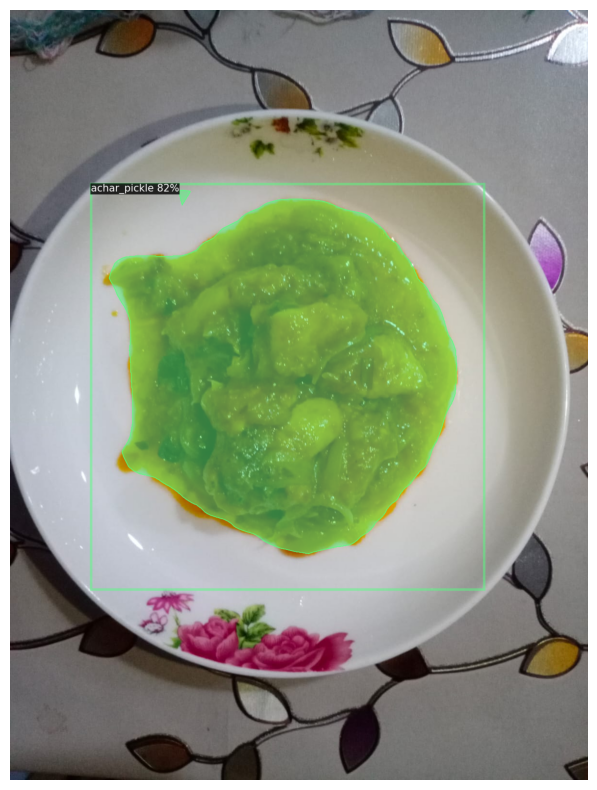

In [17]:
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [18]:
CHECKPOINT_PATH = "/content/drive/MyDrive/MaskRCNN-SEGFULL/model_0084999.pth"

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)



In [19]:

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 86
cfg.MODEL.WEIGHTS = CHECKPOINT_PATH
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5 # confidence threshold
predictor = DefaultPredictor(cfg)

[02/20 19:44:08 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/MaskRCNN-SEGFULL/model_0084999.pth ...


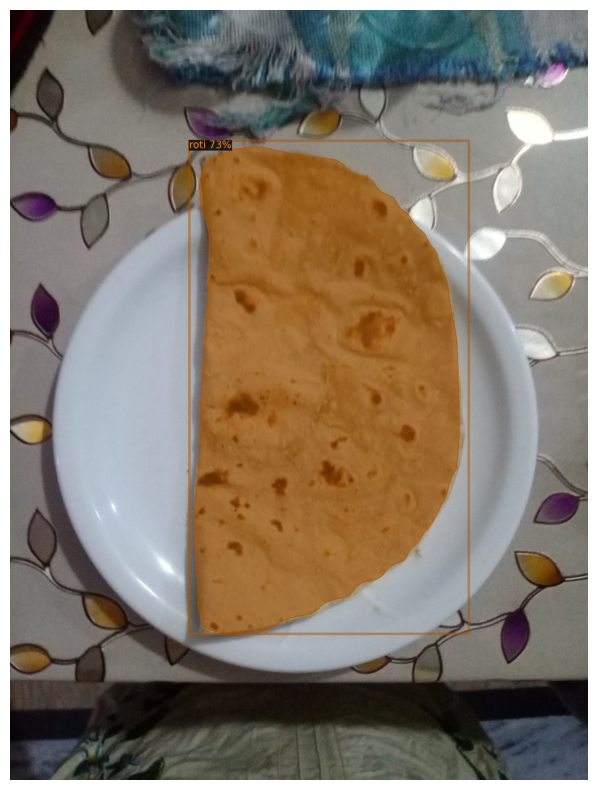

In [23]:
img_path = "/content/drive/MyDrive/segmentationTesting/seg-test-12.jpeg"

img = cv2.imread(img_path)
assert img is not None, "❌ Image not found!"
outputs = predictor(img)
metadata = MetadataCatalog.get("pak_food_train")

v = Visualizer(
    img[:, :, ::-1],  # BGR → RGB
    metadata=metadata,
    scale=1.0
)

out = v.draw_instance_predictions(
    outputs["instances"].to("cpu")
)

plt.figure(figsize=(10, 10))
plt.imshow(out.get_image())
plt.axis("off")
plt.show()

In [24]:
import numpy as np

def get_mask_rcnn_output_from_predictor(image_path, predictor, metadata, score_thresh=0.5):
    """
    Uses your Detectron2 predictor
    Returns:
    - masks: List[np.ndarray] (binary HxW)
    - labels: List[str]
    """

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be read")

    outputs = predictor(img)
    instances = outputs["instances"].to("cpu")

    if not instances.has("pred_masks"):
        return [], []

    scores = instances.scores.numpy()
    masks  = instances.pred_masks.numpy()   # (N, H, W)
    classes = instances.pred_classes.numpy()

    final_masks = []
    final_labels = []

    for i in range(len(scores)):
        if scores[i] < score_thresh:
            continue

        binary_mask = masks[i].astype(np.uint8)
        class_name = metadata.thing_classes[classes[i]]

        final_masks.append(binary_mask)
        final_labels.append(class_name)

    return final_masks, final_labels

In [25]:
img_path = "/content/drive/MyDrive/segmentationTesting/seg-test-12.jpeg"

masks, labels = get_mask_rcnn_output_from_predictor(
    image_path=img_path,
    predictor=predictor,
    metadata=metadata,
    score_thresh=0.5
)

print("Detected objects:")
for l, m in zip(labels, masks):
    print(f"{l} → pixels: {np.sum(m)}")

Detected objects:
roti → pixels: 451837


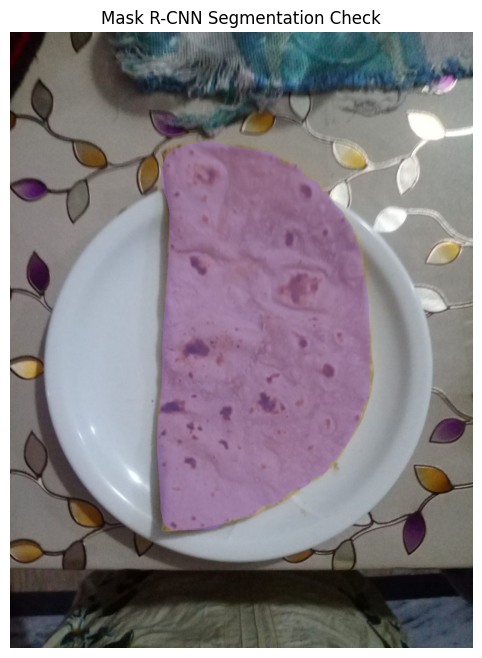

In [26]:
img = cv2.imread(img_path)

for mask, label in zip(masks, labels):
    color = np.random.randint(0, 255, size=3)
    img[mask == 1] = img[mask == 1] * 0.5 + color * 0.5

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Mask R-CNN Segmentation Check")
plt.axis("off")
plt.show()

In [29]:
import pandas as pd

DENSITY_CSV = "/content/drive/MyDrive/pakistani_food_nutrients_template_Updated.csv"

df = pd.read_csv(DENSITY_CSV)

# CSV format assumed:
# Food_Name , Density_g_per_cm3
density_map = dict(zip(df.iloc[:, 0], df.iloc[:, 1]))

print("Loaded densities:", len(density_map))
print(list(density_map.items())[:5])

Loaded densities: 84
[('white_rice', 0.6), ('jeera_rice', 0.6), ('chicken_pulao', 0.85), ('beef_pulao', 0.88), ('chicken_biryani', 0.85)]


In [30]:
# ================================
# 🔹 SINGLE IMAGE PORTION ESTIMATION (Mask R-CNN)
# ================================

img_path = "/content/drive/MyDrive/segmentationTesting/seg-test-12.jpeg"

# ---- Read image ----
image = cv2.imread(img_path)
assert image is not None, "Image not found"

# ---- Depth ----
depth_normalized = get_depth_map(image)

table_depth_norm = np.percentile(depth_normalized, 95)
depth_real_cm = (depth_normalized / table_depth_norm) * CAMERA_HEIGHT_CM

# ---- Mask R-CNN inference ----
masks, labels = get_mask_rcnn_output_from_predictor(
    image_path=img_path,
    predictor=predictor,
    metadata=metadata,
    score_thresh=0.5
)

print("\nOBJECT ESTIMATIONS")
print("-" * 50)

total_weight = 0.0

for i, (mask, class_name) in enumerate(zip(masks, labels)):

    # Area
    mask_area_pixels = np.sum(mask)
    area_cm2 = mask_area_pixels * AREA_CONVERSION_FACTOR

    # Depth → height
    object_depth_values = depth_real_cm[mask == 1]
    mean_depth_cm = np.mean(object_depth_values)

    height_cm = CAMERA_HEIGHT_CM - mean_depth_cm
    height_cm = np.clip(height_cm, 0, CAMERA_HEIGHT_CM)

    # Volume
    volume_cm3 = area_cm2 * height_cm

    # Weight
    weight_g = None
    if class_name in density_map:
        weight_g = volume_cm3 * density_map[class_name]
        total_weight += weight_g

    print(f"\n{i+1}. {class_name}")
    print(f"   Area:   {area_cm2:.2f} cm²")
    print(f"   Height: {height_cm:.2f} cm")
    print(f"   Volume: {volume_cm3:.2f} cm³")
    if weight_g:
        print(f"   Weight: {weight_g:.2f} g")

print("-" * 50)
print(f"TOTAL WEIGHT: {total_weight:.2f} g")


OBJECT ESTIMATIONS
--------------------------------------------------

1. roti
   Area:   113.84 cm²
   Height: 7.06 cm
   Volume: 803.16 cm³
   Weight: 642.53 g
--------------------------------------------------
TOTAL WEIGHT: 642.53 g


In [33]:
# =============================
# LOAD MIDAS (DEPTH)
# =============================
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)

midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.small_transform


def get_depth_map(image):
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    input_batch = transform(img_rgb).to(device)

    with torch.no_grad():
        prediction = midas(input_batch)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img_rgb.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth = prediction.cpu().numpy()
    depth = (depth - depth.min()) / (depth.max() - depth.min())
    return depth



Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [34]:
import pandas as pd

DENSITY_CSV = "/content/drive/MyDrive/pakistani_food_nutrients_template_Updated.csv"

df = pd.read_csv(DENSITY_CSV)

def normalize_name(name):
    return name.lower().strip().replace(" ", "_")

# Normalize CSV keys
density_map = {
    normalize_name(row[0]): row[1]
    for row in df.values
}

print(f"Loaded {len(density_map)} food densities")
print("Sample:", list(density_map.items())[:5])

Loaded 84 food densities
Sample: [('white_rice', 0.6), ('jeera_rice', 0.6), ('chicken_pulao', 0.85), ('beef_pulao', 0.88), ('chicken_biryani', 0.85)]


In [35]:
# =============================
# 🔹 REFERENCE BOX (FIXED SCALE)
# =============================

# UI reference box in the image
BOX_WIDTH_PX  = 315
BOX_HEIGHT_PX = 504

# Real-world size represented by the box
REAL_WIDTH_CM  = 5.0
REAL_HEIGHT_CM = 8.0

# Camera setup
CAMERA_HEIGHT_CM = 30.0

# -----------------------------
# Pixel → cm conversion
# -----------------------------
CM_PER_PIXEL_WIDTH  = REAL_WIDTH_CM / BOX_WIDTH_PX
CM_PER_PIXEL_HEIGHT = REAL_HEIGHT_CM / BOX_HEIGHT_PX

# Area conversion factor (pixel² → cm²)
AREA_CONVERSION_FACTOR = CM_PER_PIXEL_WIDTH * CM_PER_PIXEL_HEIGHT

print("Reference Box:")
print(f"  {REAL_WIDTH_CM}cm × {REAL_HEIGHT_CM}cm")
print(f"  Pixel size: {BOX_WIDTH_PX} × {BOX_HEIGHT_PX}")
print(f"  Area factor: {AREA_CONVERSION_FACTOR:.6f} cm² / pixel")

Reference Box:
  5.0cm × 8.0cm
  Pixel size: 315 × 504
  Area factor: 0.000252 cm² / pixel


In [43]:
# ================================
# 🔹 SINGLE IMAGE PORTION ESTIMATION (Mask R-CNN + Density CSV)
# ================================

img_path = "/content/drive/MyDrive/segmentationTesting/seg-test-11.jpeg"

# ---- Read image ----
image = cv2.imread(img_path)
assert image is not None, "Image not found"

# ---- Depth ----
depth_normalized = get_depth_map(image)

table_depth_norm = np.percentile(depth_normalized, 95)
depth_real_cm = (depth_normalized / table_depth_norm) * CAMERA_HEIGHT_CM

# ---- Mask R-CNN inference ----
masks, labels = get_mask_rcnn_output_from_predictor(
    image_path=img_path,
    predictor=predictor,
    metadata=metadata,
    score_thresh=0.5
)

print("\nOBJECT ESTIMATIONS")
print("-" * 55)

total_weight = 0.0

for i, (mask, class_name) in enumerate(zip(masks, labels)):

    class_name_norm = normalize_name(class_name)

    # ---- Area ----
    mask_area_pixels = np.sum(mask)
    area_cm2 = mask_area_pixels * AREA_CONVERSION_FACTOR

    # ---- Height (from depth) ----
    object_depth_values = depth_real_cm[mask == 1]
    mean_depth_cm = np.mean(object_depth_values)

    height_cm = CAMERA_HEIGHT_CM - mean_depth_cm
    height_cm = np.clip(height_cm, 0, CAMERA_HEIGHT_CM)

    # ---- Volume ----
    volume_cm3 = area_cm2 * height_cm

    # ---- Weight (USING CSV HERE) ----
    if class_name_norm in density_map:
        density = density_map[class_name_norm]
        weight_g = volume_cm3 * density
        total_weight += weight_g
    else:
        density = None
        weight_g = None

    # ---- Output ----
    print(f"\n{i+1}. {class_name}")
    print(f"   Area:    {area_cm2:.2f} cm²")
    print(f"   Height:  {height_cm:.2f} cm")
    print(f"   Volume:  {volume_cm3:.2f} cm³")

    if weight_g is not None:
        print(f"   Density: {density:.3f} g/cm³")
        print(f"   Weight:  {weight_g:.2f} g")
    else:
        print("   ⚠️ Density not found in CSV")

print("-" * 55)
print(f"TOTAL WEIGHT: {total_weight:.2f} g")


OBJECT ESTIMATIONS
-------------------------------------------------------

1. achar_pickle
   Area:    97.84 cm²
   Height:  2.37 cm
   Volume:  232.04 cm³
   Density: 1.100 g/cm³
   Weight:  255.24 g
-------------------------------------------------------
TOTAL WEIGHT: 255.24 g


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Processing: seg-test-11.jpeg
❌ No food detected


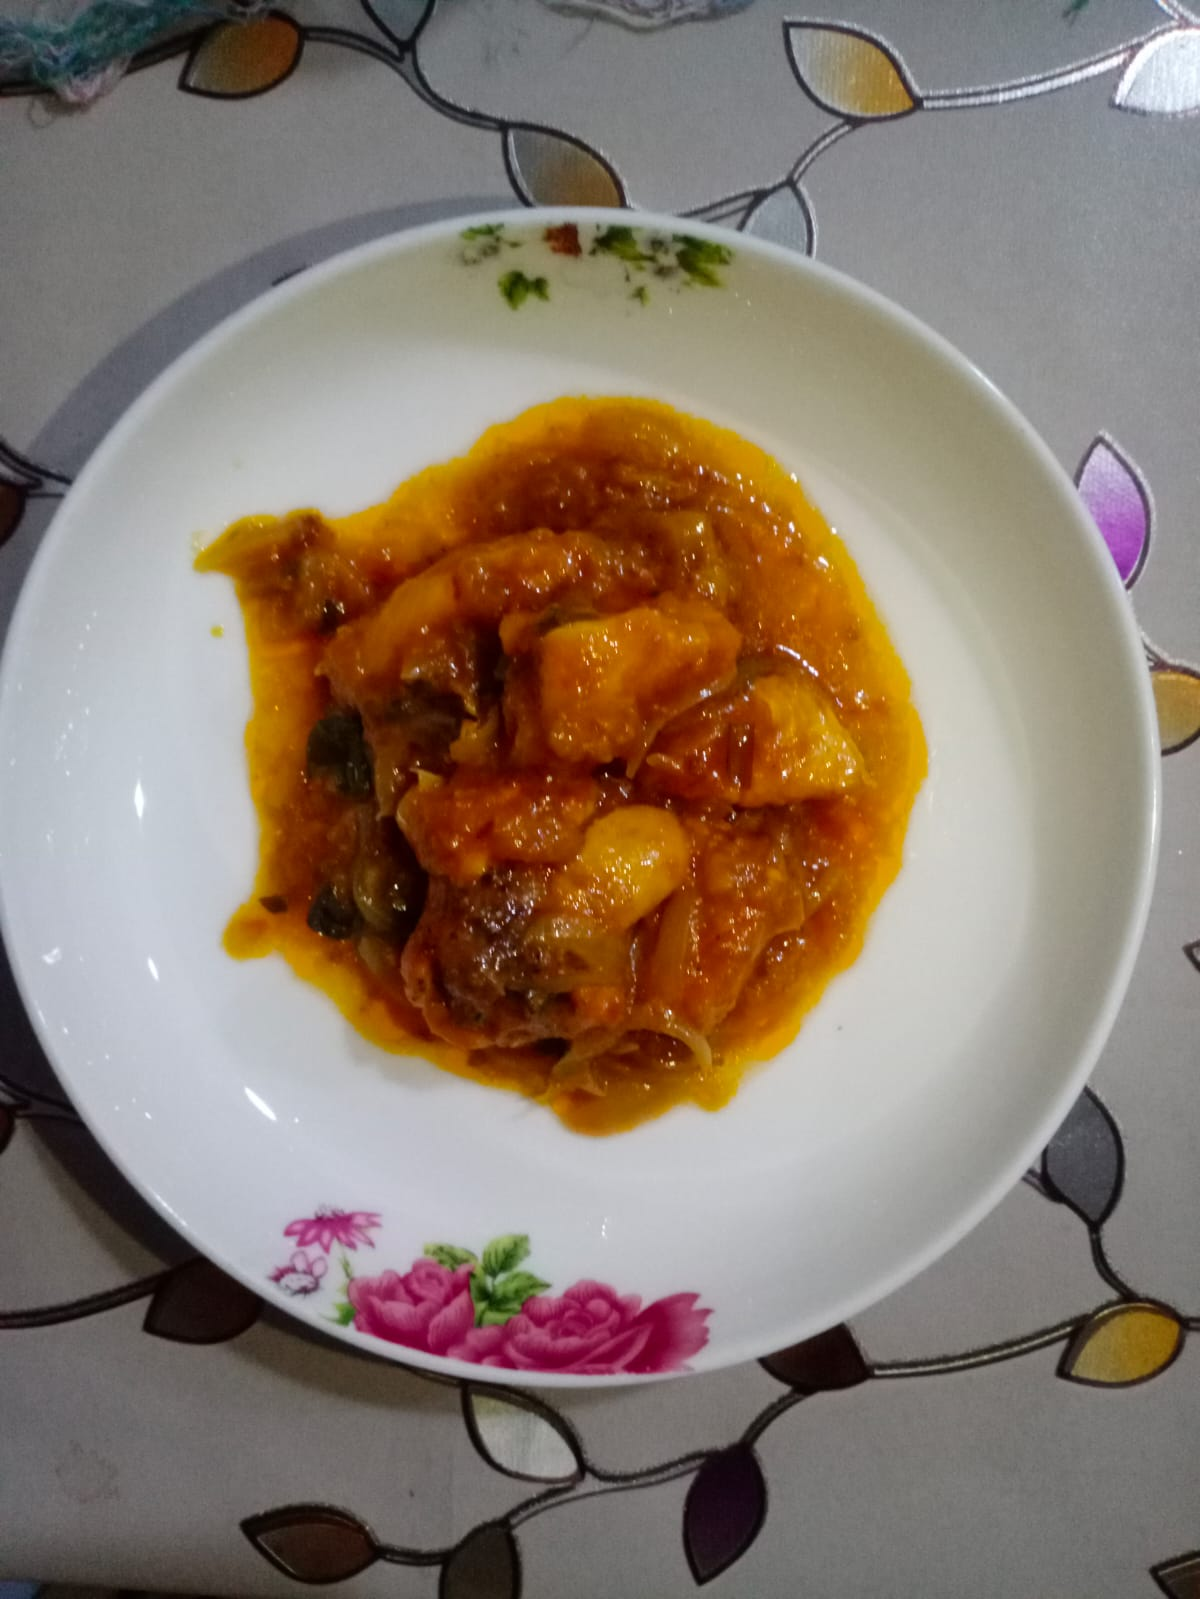

In [44]:
import cv2
import numpy as np
import torch
import pandas as pd
import os
from google.colab.patches import cv2_imshow

# =============================
# PATHS
# =============================
IMG_PATH = "/content/drive/MyDrive/segmentationTesting/seg-test-11.jpeg"
DENSITY_CSV = "/content/drive/MyDrive/pakistani_food_nutrients_template_Updated.csv"

# =============================
# REFERENCE BOX (FIXED)
# =============================
BOX_WIDTH_PX = 315
BOX_HEIGHT_PX = 504
REAL_WIDTH_CM = 5.0
REAL_HEIGHT_CM = 8.0
CAMERA_HEIGHT_CM = 30.0

CM_PER_PIXEL_WIDTH = REAL_WIDTH_CM / BOX_WIDTH_PX
CM_PER_PIXEL_HEIGHT = REAL_HEIGHT_CM / BOX_HEIGHT_PX
AREA_CONVERSION_FACTOR = CM_PER_PIXEL_WIDTH * CM_PER_PIXEL_HEIGHT

# =============================
# LOAD DENSITIES
# =============================
df = pd.read_csv(DENSITY_CSV)
density_map = dict(zip(df.iloc[:, 0], df.iloc[:, 1]))

# =============================
# LOAD MIDAS (DEPTH)
# =============================
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)

midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.small_transform


def get_depth_map(image):
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    input_batch = transform(img_rgb).to(device)

    with torch.no_grad():
        prediction = midas(input_batch)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img_rgb.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth = prediction.cpu().numpy()
    depth = (depth - depth.min()) / (depth.max() - depth.min())
    return depth


# =============================
# 🔹 MASK R-CNN OUTPUT FUNCTION
# =============================
def get_mask_rcnn_output(image):
    """
    🔴 REPLACE THIS with your actual Mask R-CNN inference
    MUST return:
    - masks: List[np.ndarray] -> binary (H,W)
    - labels: List[str]
    """

    # Example placeholder
    masks = []      # e.g. [mask1, mask2]
    labels = []     # e.g. ["chicken_biryani", "raita"]

    return masks, labels


# =============================
# MAIN PROCESS
# =============================
def process_single_image(img_path):
    image = cv2.imread(img_path)
    assert image is not None, "Image not found!"

    print("Processing:", os.path.basename(img_path))

    depth_norm = get_depth_map(image)
    table_depth = np.percentile(depth_norm, 95)
    depth_real = (depth_norm / table_depth) * CAMERA_HEIGHT_CM

    masks, labels = get_mask_rcnn_output(image)

    if len(masks) == 0:
        print("❌ No food detected")
        cv2_imshow(image)
        return

    total_weight = 0.0
    vis = image.copy()

    print("\nOBJECT ESTIMATIONS")
    print("-" * 40)

    for i, (mask, label) in enumerate(zip(masks, labels)):

        if mask.shape != image.shape[:2]:
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]))

        binary_mask = (mask > 0.5).astype(np.uint8)

        area_pixels = np.sum(binary_mask)
        area_cm2 = area_pixels * AREA_CONVERSION_FACTOR

        depth_vals = depth_real[binary_mask == 1]
        mean_depth = np.mean(depth_vals)

        height_cm = max(0, CAMERA_HEIGHT_CM - mean_depth)
        volume_cm3 = area_cm2 * height_cm

        weight = None
        if label in density_map:
            weight = volume_cm3 * density_map[label]
            total_weight += weight

        # ---- Draw contour ----
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(vis, contours, -1, (0, 255, 0), 2)

        if contours:
            x, y, w, h = cv2.boundingRect(contours[0])
            txt = f"{label}"
            cv2.putText(vis, txt, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        print(f"\n{i+1}. {label}")
        print(f"   Area: {area_cm2:.2f} cm²")
        print(f"   Height: {height_cm:.2f} cm")
        print(f"   Volume: {volume_cm3:.2f} cm³")
        if weight:
            print(f"   Weight: {weight:.2f} g")

    print("-" * 40)
    print(f"TOTAL WEIGHT: {total_weight:.2f} g")

    cv2_imshow(vis)


# =============================
# RUN
# =============================
process_single_image(IMG_PATH)